# Разработка алгоритма жадного добавления

Для сравнительной оценки получаемых результатов с подходом описанным в СП 11.13130.2009

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

# Загрузка исходных данных

Здесь используем данные для Сосновоборска, как тестовые.

In [ ]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# Загружаем данные
G = ox.load_graphml(r'tests\data\test_rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# # Создаем реверсный граф
# GR = nx.reverse(G, copy=True)

# Загрузка зданий
buildings = gpd.read_file(r'tests\data\buildings.gpkg')

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)


# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)
print('Узлов исходного ГДС:', len(nodes_gdf))

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

fig, ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
buildings.plot(ax=ax)

# 1. Разработка алгоритма

## 1.2. Расчет матрицы достижимости от всех зданий

In [ ]:
buildings.head(5)

In [ ]:
from genesis.swiss_knife import MSF
from genesis.utils import Progressbar, TimeCheckPoint

time_bound = 9


df_size = len(buildings)
pb = Progressbar(df_size, bins=40)
t = TimeCheckPoint()

d = {}
for id, building in buildings.iterrows():
    node = building['node']
    length = nx.shortest_path_length(G, target = node, weight = 'travel_time')
    length = {k:v for k,v in length.items() if v <= time_bound}   
    d[id] = pd.Series(length).notna()
    pb()

matrix = pd.DataFrame(d).T
matrix.shape

print('Потребовалось времени:', t())

In [ ]:
matrix

In [ ]:
matrix.to_csv('greedy_adding_matrix.csv')

## 1.3. Алгоритм

1. Если матрица не равна нулю (имеется хоть одна строка или неприкрытое здание) увеличиваем количество мест размещения на 1.
Ищем максимальную сумму среди всех узлов - это тот у зел, размещение в котором обеспечит покрытие максимального количества зданий
2. Определяем его номер
3. Поэтому номеру получаем маску покрытых узлов
4. Из матрицы достижимости выбрасываем все узлы покрытые имеющимся размещением

5. Повторяем все предыдущие шаги до тех пор пока не закончится вся матрица

In [ ]:
# pd.set_option('future.no_silent_downcasting', True)

In [ ]:
matrix_temp = matrix.copy()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)
    # node_column = node_column.fillna(False)

    # # Определения количества прикрытых зданий
    # nodes_list = list(node_column[node_column].index)
    # covered_buildings_count += len(buildings.query(f'node in @nodes_list'))
    # print(len(buildings.query(f'node in @nodes_list')), covered_buildings_count)

    matrix_temp = matrix_temp[node_column.isna()]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r')
    # print(matrix_temp.shape, len(units), 100 * (covered_buildings_count / len(buildings)), ' '*5)    

In [ ]:
units

In [ ]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)

fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[units].plot(ax=ax, color='red', edgecolor='black')


# 2. Сопоставление со временем расчета для инструментов **genesis**

Проверка для полученных жадным добавлением размещений

In [ ]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding, CoverIndexBuilding


time_bound = 10

dynamic_nodes = {}
i = 0
for n in units[:2]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))


nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[dynamic_nodes.keys()].plot(ax=ax, color='red', edgecolor='black')

In [2]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState


def iter_func(**kwds):
    'Функция вывода хода расчета'
    i = kwds['i']
    best_metric = kwds['best_metric']
    print(f'Копт: шаг {i} лучшая метирка: {best_metric}')

def mclp_end_function(iteration, best_metric, dynamic_nodes, static_nodes, **kwargs):
    units_count = len(dynamic_nodes) + len(static_nodes)
    msg = f'Итерация: {iteration} | Подразделений {units_count} | Лучшая метрика: {best_metric}'
    print(msg)


def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

def stop_case_function(target_ip=90,
                            ip_val=10):
    def stop_case_function_(value,
                            iteration,
                            best_metric,
                            current_metric,
                            dynamic_nodes,
                            static_nodes,
                            ):

        ip = value
        print(f'Текущий ИП-{ip_val}:', ip, target_ip)
        if ip >= target_ip:
            return True
        return False
    
    return stop_case_function_

def print_metrics(env, dynamic_nodes, existed_units_dict, ip_val=3):
    all_nodes = {**existed_units_dict, **dynamic_nodes}
    times, _ = FirstArrivalUnitState()(env = env, points = all_nodes)
    print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(all_nodes))
    print(f'ИП-{ip_val} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times))

In [ ]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.metrics import ArrivalTimeBuilding
from fire_units.mclp import BestNodesGAKopt
from genesis.best_points import BestNodeBee
from genesis.mclp import BestNodesKoptG
from genesis.point_selectors import RandomNodesSelector
from genesis.stop_cases import NSameStopCase


time_bound = 10


dynamic_nodes = {}
i = 0
for n in units[:2]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))

metric_target = CoverIndexBuilding(buildings, ip_val = time_bound)
# metric_target = ArrivalTimeBuilding(buildings)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
abc = BestNodeBee(state_function=FirstArrivalUnitState(),
                  metric_function=ArrivalTime(),
                  scouts_count=20,
                  best_scouts_count=4)


kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=abc,
                       iterations=4,
                       iter_calc_end_function=iter_func,
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 200,
                    epochs = 25,
                    elite_size = 25,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 10,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )



best_dynamic_nodes, best_metric = kopt(env = G,
                                dynamic_nodes = dynamic_nodes,
                                )

times, _ = FirstArrivalUnitState()(env = G, points = best_dynamic_nodes)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), metric_target(times))

In [ ]:

from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import CoverIndexBuilding
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import NSameStopCase


time_bound = 10
target_ip  = 99





# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 75,
                    epochs = 25,
                    elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 5,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


genesis = LSCPCommon(
                    mclp_function = gakopt,
                    # mclp_function = kopt,
                    point_selector = RandomNodesSelector(),
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),
                    metric_function = metric_target,                        
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
                    start_names_index = 3,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {
    list(nodes_gdf.index)[100]: 'псч 1',
    list(nodes_gdf.index)[200]: 'псч 2',
}

t()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())


times, _ = FirstArrivalUnitState()(env = G, points = optimal_nodes)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))

# Тест времени расчета для графа Красноярска

In [3]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# G = ox.load_graphml(r'C:\QGIS\Красноярск Демо\______________ef3f7396_30d9_4d94_b617_55ad61b06e30.ml')
G = ox.load_graphml(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)

31293 77344


g:\GitRepositories\_Dislocation\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


In [4]:
# Загрузка зданий
# buildings = gpd.read_file(r'C:\QGIS\Красноярск Демо\data\bld.gpkg')
buildings = gpd.read_file(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')


# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

Зданий: 58094
Зданий: 51317


#### Определение субсета данных о зданиях

In [5]:
df_size = int(len(buildings) * 0.2)
buildings_set = buildings.sample(df_size)
print(f'Расчет для {df_size} зданий')

Расчет для 10263 зданий


#### Расчет матрицы с использованием зданий в качестве цели

    nx.shortest_path_length

In [ ]:
from genesis.utils import Progressbar, TimeCheckPoint

time_bound = 9



print(f'Расчет для {df_size} зданий')
pb = Progressbar(df_size, bins=40)
t = TimeCheckPoint()

d = {}
# for id, building in buildings.sample(df_size).iterrows():
for id, building in buildings_set.iterrows():
    node = building['node']
    length = nx.shortest_path_length(G, target = node, weight = 'travel_time')
    length = {k:v for k,v in length.items() if v <= time_bound}   
    d[id] = pd.Series(length).notna()
    pb()

matrix = pd.DataFrame(d).T
print('Размер матрицы:', matrix.shape)

print('Потребовалось времени:', t())

In [ ]:
matrix_temp = matrix.copy()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    # Определения количества прикрытых зданий
    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)

    matrix_temp = matrix_temp[node_column.isna()]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r') 

#### Расчет матрицы с использованием `cutoff` и реверсного графа

    nx.multi_source_dijkstra_path_length

In [6]:
from genesis.utils import Progressbar, TimeCheckPoint

GR = nx.reverse(G, copy=True)

time_bound = 9


print(f'Расчет для {df_size} зданий')
pb = Progressbar(df_size, bins=40)
t = TimeCheckPoint()

d = {}
for id, building in buildings_set.iterrows():
    node = building['node']
    length = nx.multi_source_dijkstra_path_length(GR, sources=[node], weight = 'travel_time', cutoff=time_bound)
    d[id] = pd.Series(length) 
    pb()

matrix = pd.DataFrame(d).T
print('Размер матрицы:', matrix.shape)

print('Потребовалось времени:', t())

Расчет для 10263 зданий
|########################################| 100.0%
Размер матрицы: (10263, 30978)
Потребовалось времени: 261.54


In [7]:
matrix_temp = matrix.copy().notna()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    # node_id = matrix_temp.columns[np.argmax(matrix_temp.sum())]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    # Определения количества прикрытых зданий
    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)

    matrix_temp = matrix_temp[node_column == False]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r') 

10263
Прикрыто зданий 2617 и всего: 2617 узел: 420043078
(7646, 30978) 1 25.499366656922927      
Прикрыто зданий 2566 и всего: 5183 узел: 7596487837
(5080, 30978) 2 50.501802591834746      
Прикрыто зданий 1426 и всего: 6609 узел: 3774635420
(3654, 30978) 3 64.3963753288512      
Прикрыто зданий 1010 и всего: 7619 узел: 1537263273
(2644, 30978) 4 74.2375523726006      
Прикрыто зданий 839 и всего: 8458 узел: 3281639677
(1805, 30978) 5 82.4125499366657      
Прикрыто зданий 328 и всего: 8786 узел: 427618859
(1477, 30978) 6 85.60849654097242      
Прикрыто зданий 284 и всего: 9070 узел: 357878446
(1193, 30978) 7 88.37571860079899      
Прикрыто зданий 281 и всего: 9351 узел: 2127094731
(912, 30978) 8 91.11370944168372      
Прикрыто зданий 153 и всего: 9504 узел: 1280859608
(759, 30978) 9 92.60450160771704      
Прикрыто зданий 150 и всего: 9654 узел: 1537263234
(609, 30978) 10 94.06606255480854      
Прикрыто зданий 100 и всего: 9754 узел: 429333203
(509, 30978) 11 95.0404365195362    

### Расчет с использованием методов Genesis

In [8]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean, BestNodeHillClimbing_maxMean_Metric
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import CoverIndexBuilding, ArrivalTimeBuilding
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.best_points import BestNodeHillClimbing
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector, FarNodeSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import NSameStopCase
from genesis.utils import Progressbar, TimeCheckPoint

#### Оценка предложенного размещения

Исходно
Новых ПСЧ: 3 Всего ПСЧ: 50
ИП-10 =  64.51581413510347 %, tпр =  12.17435603184736 10.339503270201448


<Axes: >

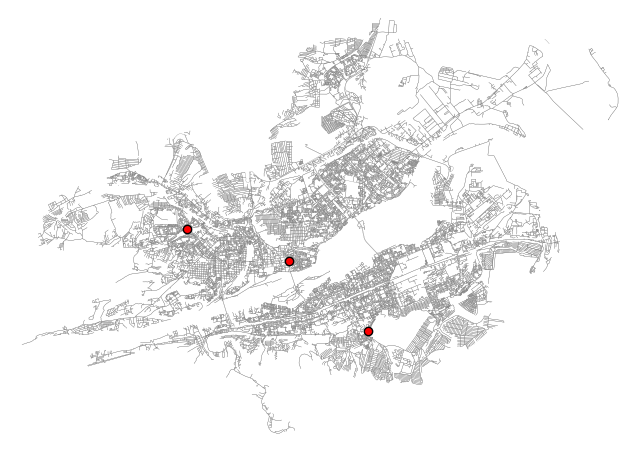

In [9]:
time_bound = 10

dynamic_nodes = {}
i = 0
for n in units[:3]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ',
      CoverIndexBuilding(buildings_set, ip_val = time_bound)(times),
      '%, tпр = ', ArrivalTime()(times),
      ArrivalTimeBuilding(buildings_set)(times))

# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[dynamic_nodes.keys()].plot(ax=ax, color='red', edgecolor='black')

#### Расчет при помощи ГА + Генезис

In [11]:



time_bound = 10
target_ip  = 99





# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings_set, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
# bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
bnhc = BestNodeHillClimbing_maxMean_Metric(state_function=FirstArrivalUnitState(), metric_function=metric_target)
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTimeBuilding(buildings_set))
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=metric_target)

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                    #    metric_function = ArrivalTime(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=6,
                       iter_calc_end_function=iter_func,
                       stop_case_function = NSameStopCase(3),      # Условие остановки не менее N одинаковых метрик
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 30,
                    epochs = 20,
                    elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 0.8,
                    mutation_rate = 1,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


genesis = LSCPCommon(
                    mclp_function = gakopt,
                    # mclp_function = kopt,
                    # point_selector = RandomNodesSelector(),
                    point_selector = FarNodeSelector(FirstArrivalUnitState()),                    
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),
                    metric_function = metric_target,                        
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
                    start_names_index = 100,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {
    list(nodes_gdf.index)[1000]: 'псч 1',
    list(nodes_gdf.index)[2000]: 'псч 2',
    list(nodes_gdf.index)[3000]: 'псч 3',
    list(nodes_gdf.index)[4000]: 'псч 4',
    list(nodes_gdf.index)[5000]: 'псч 5',
    list(nodes_gdf.index)[6000]: 'псч 6',
    # list(nodes_gdf.index)[2000]: 'псч 2',
    # list(nodes_gdf.index)[2000]: 'псч 2',
}

t = TimeCheckPoint()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())


times, _ = FirstArrivalUnitState()(env = G, points = optimal_nodes)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))

До LSCP: 6
Эпоха: 0 | Лучшая метрика: 63.52987114408434 | Текущая метрика: 63.52987114408434 |
Эпоха: 1 | Лучшая метрика: 65.20890277235455 | Текущая метрика: 65.20890277235455 |
Эпоха: 2 | Лучшая метрика: 65.20890277235455 | Текущая метрика: 65.20890277235455 |
Эпоха: 3 | Лучшая метрика: 65.20890277235455 | Текущая метрика: 65.20890277235455 |
Эпоха: 4 | Лучшая метрика: 66.16556032799687 | Текущая метрика: 66.16556032799687 |
Эпоха: 5 | Лучшая метрика: 66.16556032799687 | Текущая метрика: 66.16556032799687 |
Эпоха: 6 | Лучшая метрика: 66.16556032799687 | Текущая метрика: 66.16556032799687 |
Эпоха: 7 | Лучшая метрика: 66.16556032799687 | Текущая метрика: 66.16556032799687 |
Эпоха: 8 | Лучшая метрика: 66.16556032799687 | Текущая метрика: 66.16556032799687 |
Эпоха: 9 | Лучшая метрика: 69.14291292463881 | Текущая метрика: 69.14291292463881 |
Эпоха: 10 | Лучшая метрика: 69.14291292463881 | Текущая метрика: 69.14291292463881 |
Эпоха: 11 | Лучшая метрика: 69.14291292463881 | Текущая метрика:

KeyboardInterrupt: 

#### Попытка улучшить полученное размещение

In [ ]:
time_bound = 10
target_ip  = 90





# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings_set, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
# bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
bnhc = BestNodeHillClimbing_maxMean_Metric(state_function=FirstArrivalUnitState(), metric_function=metric_target)
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTimeBuilding(buildings_set))
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=metric_target)

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 60,
                    epochs = 20,
                    elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 2,
                    mutation_rate = 1,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


# genesis = LSCPCommon(
#                     mclp_function = gakopt,
#                     # mclp_function = kopt,
#                     # point_selector = RandomNodesSelector(),
#                     point_selector = FarNodeSelector(FirstArrivalUnitState()),                    
#                     # point_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),
#                     metric_function = metric_target,                        
#                     # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
#                     stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
#                     start_names_index = 100,
#                     names_pattern='псч {}',
#                     after_mclp_function = mclp_end_function,
#                     )

dynamic_nodes = {}
i = 0
for n in units[:3]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))



t = TimeCheckPoint()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = gakopt(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())

# Проверка объединения наборов данных

In [ ]:
dynamic_nodes = {}
i = 0
for n in units[:5]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, nearest = FirstArrivalUnitState()(env = G, points = dynamic_nodes)

In [ ]:
print(len(times), len(nearest))
nearest2 = nearest[nearest == 'pre 0']
times2 = times.loc[nearest2.keys()]
print(len(times2), len(nearest2))

In [ ]:
len(buildings)

In [ ]:
merged_df = pd.merge(buildings,
                    times2,
                    how         = 'left',
                    left_on     = 'node',
                    right_index = True)
print('left', len(merged_df))

merged_df = pd.merge(buildings,
                    times2,
                    how         = 'right',
                    left_on     = 'node',
                    right_index = True)
print('right', len(merged_df))

merged_df = pd.merge(buildings,
                    times2,
                    how         = 'outer',
                    left_on     = 'node',
                    right_index = True)
print('outer', len(merged_df))

merged_df = pd.merge(buildings,
                    times2,
                    how         = 'inner',
                    left_on     = 'node',
                    right_index = True)
print('inner', len(merged_df))


In [ ]:
buildings_s = buildings.query(f'node in @times2.keys()')
print('Зданий', len(buildings_s), 'Времен', len(times2))

merged_df = pd.merge(buildings_s,
                    times,
                    how         = 'left',
                    left_on     = 'node',
                    right_index = True)

print('left', len(merged_df))

In [ ]:
merged_df